# Generate dataset with GW data

Imports, include the project root in the Python path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal as _lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

PROJECT_ROOT: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe
cwd: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
sys.path: ['/home/victor/gw/Gravitational-Waves-Lab/cbc_pe', '/home/victor/miniconda3/envs/gw-env/lib/python311.zip', '/home/victor/miniconda3/envs/gw-env/lib/python3.11', '/home/victor/miniconda3/envs/gw-env/lib/python3.11/lib-dynload', '']


In [2]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import ParameterSampler
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector
from src.noise import NoiseModel
from src.injection import SignalInjector
from src.processing import SignalProcessor
from src.labels import LabelTransformer
from src.dataset import DatasetBuilder

Define the simulation configuration for the signals. 
And the processing configuration for the data.

#### Para sistemas cuya duración en banda excede la ventana de análisis, el dataset no contiene la inspiral completa. Se conserva la porción final de la señal dentro de una ventana fija de 4 s, garantizando que al menos el último segundo antes de la coalescencia esté presente. El SNR y el reescalado de distancia se calculan sobre la señal efectivamente usada para la inyección.

In [10]:
config = SimulationConfig(
    sampling_frequency = 4096.0,  # Hz
    duration = 4.0,  # s
    low_frequency_cutoff = 30.0,  # Hz
    waveform_approximant ="SEOBNRv4_opt",
    target_network_snr_range = (10.0, 25.0),
    snr_relative_tolerance = 0.05,
)

signal_processor_dict = {
    "apply_whitening": False, 
    "apply_lowpass": False, 
    "apply_highpass": False, 
    "apply_standardization": False,
    "preserve_length": True, 
}

Once the config is set up, we can generate the dataset with the DatasetBuilder class.

In [11]:
rng = np.random.default_rng(1234)

builder = DatasetBuilder.from_config(
    config=config,
    detector_names=["H1", "L1", "V1"],
    signal_processor_kwargs=signal_processor_dict,
    label_transformer_kwargs={},
    rng=rng,
)

In [12]:
#Check for one sample
sample = builder.build_sample()

print("X shape:", sample.X.shape)
print("y shape:", sample.y.shape)
print("y:", sample.y)
print("parameters:", sample.parameters)

print("Final SNR:", sample.metadata["snr"]["final_network_snr"])
print("SNR rescaled:", sample.metadata["snr"]["snr_rescaled"])
print("SNR reason:", sample.metadata["snr"]["snr_rescaling_reason"])

print("Windowing:", sample.metadata["windowing"])
print("Placement:", sample.metadata["placement"])
print("Injection:", sample.metadata["injection"])

X shape: (3, 16384)
y shape: (3,)
y: [ 49.00873966 125.33611765  -0.47075497]
parameters: CBCParameters(mass_1=88.01948016934209, mass_2=37.31663747666751, distance=1201.939634065736, inclination=np.float64(2.06759669959222), ra=2.004945948992312, dec=np.float64(-0.8692072862628579), spin_1z=-0.5164674134944298, spin_2z=-0.36293214243554717, polarization_angle=6.05748854826156)
Final SNR: 16.615091830802672
SNR rescaled: True
SNR reason: outside_target_range
Windowing: {'is_truncated': False, 'truncation_policy': 'keep_last_segment', 'detector_names': ['H1', 'L1', 'V1'], 'full_network_start_time': 1126259461.946045, 'full_network_end_time': 1126259462.2521973, 'full_network_duration': 0.30615234375, 'used_window_start_time': 1126259461.946045, 'used_window_end_time': 1126259462.2521973, 'used_window_duration': 0.30615234375, 'segment_duration': 4.0, 'required_final_duration': 1.0, 'required_available_final_duration': 0.30615234375, 'seconds_before_network_end_in_window': 0.30615234375,

In [13]:
#Hard checks
assert sample.X.shape == (3, config.length)
assert sample.y.shape == (3,)
assert np.all(np.isfinite(sample.X))
assert np.all(np.isfinite(sample.y))

low, high = config.target_network_snr_range
snr = sample.metadata["snr"]["final_network_snr"]

assert low * (1 - config.snr_relative_tolerance) <= snr
assert snr <= high * (1 + config.snr_relative_tolerance)

for det in sample.metadata["detectors"]:
    inj = sample.metadata["injection"][det]
    assert not inj["is_partially_clipped"]
    assert inj["n_signal_samples"] == inj["n_injected_samples"]

assert sample.parameters.mass_1 >= sample.parameters.mass_2
assert sample.parameters.mass_2 >= 5.0

print("Single sample sanity check OK")

Single sample sanity check OK


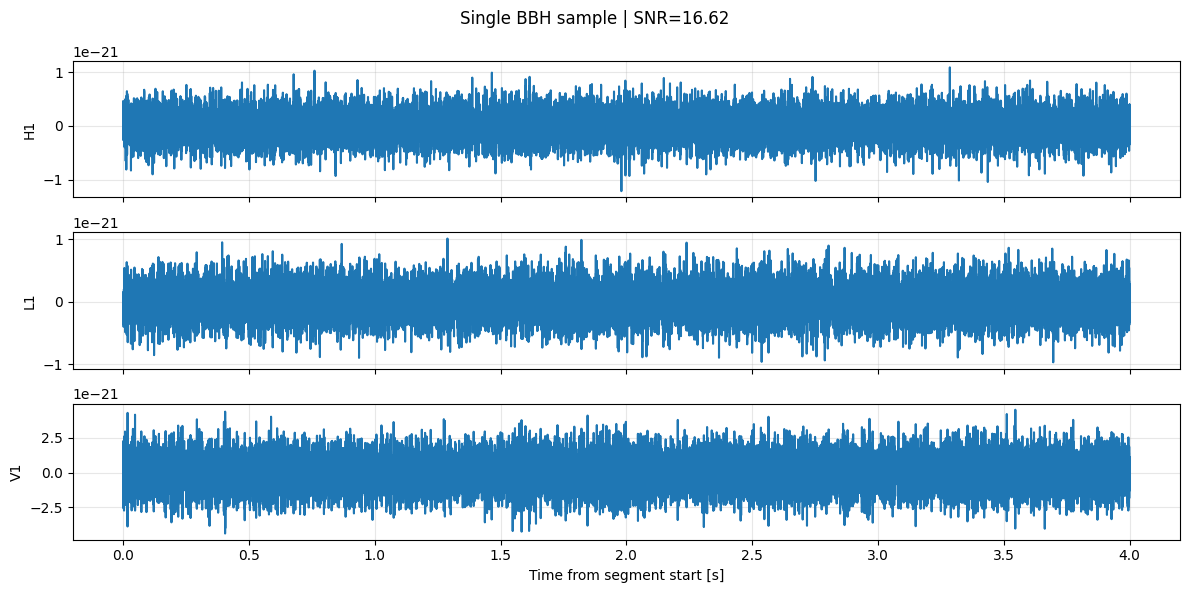

In [14]:
def plot_sample(sample, config, title=None):
    detectors = sample.metadata["detectors"]
    t = np.arange(config.length) * config.delta_t

    fig, axes = plt.subplots(len(detectors), 1, figsize=(12, 6), sharex=True)

    if len(detectors) == 1:
        axes = [axes]

    for i, det in enumerate(detectors):
        axes[i].plot(t, sample.X[i])
        axes[i].set_ylabel(det)
        axes[i].grid(alpha=0.3)

    axes[-1].set_xlabel("Time from segment start [s]")

    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()


plot_sample(
    sample,
    config,
    title=f"Single BBH sample | SNR={sample.metadata['snr']['final_network_snr']:.2f}",
)

In [15]:
# Now for 10 samples
batch10 = builder.build_dataset(num_samples=10)

print("X shape:", batch10.X.shape)
print("y shape:", batch10.y.shape)
print("n parameters:", len(batch10.parameters))
print("n metadata:", len(batch10.metadata))

Built sample 10 of 10 --> 100.0% completed (attempts=10, failed=0)
--> DATASET GENERATED with 10 valid samples after 10 attempts. Failed samples: 0.
X shape: (10, 3, 16384)
y shape: (10, 3)
n parameters: 10
n metadata: 10


In [16]:
#Checks
assert batch10.X.shape == (10, 3, config.length)
assert batch10.y.shape == (10, 3)
assert len(batch10.parameters) == 10
assert len(batch10.metadata) == 10
assert np.all(np.isfinite(batch10.X))
assert np.all(np.isfinite(batch10.y))

print("Batch 10 basic shape check OK")

Batch 10 basic shape check OK


In [17]:
#Check SNR, mass, cuts, clips and margin distributions
snrs = np.array([
    m["snr"]["final_network_snr"]
    for m in batch10.metadata
])

initial_snrs = np.array([
    m["snr"]["initial_network_snr"]
    for m in batch10.metadata
])

rescaled = np.array([
    m["snr"]["snr_rescaled"]
    for m in batch10.metadata
])

truncated = np.array([
    m["windowing"]["is_truncated"]
    for m in batch10.metadata
])

margins_respected = np.array([
    m["placement"].get("margins_respected", None)
    for m in batch10.metadata
])

any_clipped = np.array([
    any(m["injection"][det]["is_partially_clipped"] for det in m["detectors"])
    for m in batch10.metadata
])

m1 = np.array([p.mass_1 for p in batch10.parameters])
m2 = np.array([p.mass_2 for p in batch10.parameters])
dist = np.array([p.distance for p in batch10.parameters])
chirp = batch10.y[:, 0]
mtot = batch10.y[:, 1]
chieff = batch10.y[:, 2]

print("Final SNR:", snrs)
print("Initial SNR:", initial_snrs)
print("SNR min/max:", snrs.min(), snrs.max())
print("Rescaled count:", rescaled.sum(), "/", len(rescaled))
print("Truncated count:", truncated.sum(), "/", len(truncated))
print("Any clipped count:", any_clipped.sum(), "/", len(any_clipped))

if margins_respected[0] is not None:
    print("Margins respected:", margins_respected.sum(), "/", len(margins_respected))

print("m1 range:", m1.min(), m1.max())
print("m2 range:", m2.min(), m2.max())
print("distance range:", dist.min(), dist.max())
print("chirp mass range:", chirp.min(), chirp.max())
print("total mass range:", mtot.min(), mtot.max())
print("chi_eff range:", chieff.min(), chieff.max())

Final SNR: [19.16526972 24.88388844 11.3827232  11.36714261 13.63565717 13.30240656
 16.92419983 20.30892366 24.27009327 18.23099001]
Initial SNR: [ 9.83030533 26.06977498  2.94216107 11.36714261 13.63565717  5.26772673
  3.00488989  6.80512639  3.32587041 18.23099001]
SNR min/max: 11.367142611893652 24.883888442314255
Rescaled count: 7 / 10
Truncated count: 0 / 10
Any clipped count: 0 / 10
Margins respected: 10 / 10
m1 range: 22.109504273984033 88.11038825664934
m2 range: 5.508144354206232 67.33173244196007
distance range: 567.4666840568314 4458.017476024334
chirp mass range: 9.185721018241589 61.3333533840361
total mass range: 27.617648628190267 141.08234215975483
chi_eff range: -0.5698573898377056 0.6196706244166618


In [18]:
#Checks
low, high = config.target_network_snr_range

assert np.all(snrs >= low * (1 - config.snr_relative_tolerance))
assert np.all(snrs <= high * (1 + config.snr_relative_tolerance))

assert np.all(m1 >= m2)
assert np.all(m2 >= 5.0)
assert np.all(chirp > 0)
assert np.all(mtot > 0)
assert np.all((-1.0 <= chieff) & (chieff <= 1.0))
assert not np.any(any_clipped)

print("Batch 10 physics/SNR checks OK")

Batch 10 physics/SNR checks OK


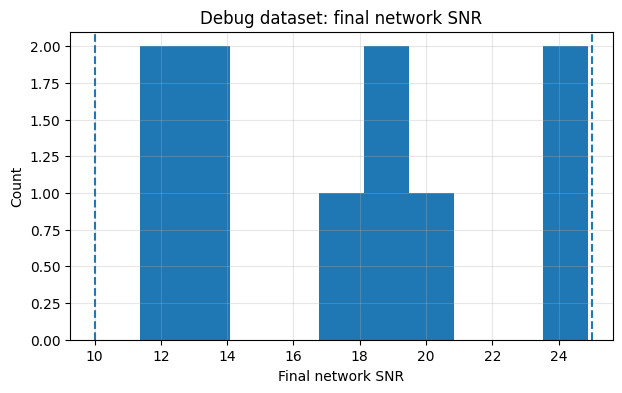

In [19]:
#Diagnostic plots
plt.figure(figsize=(7, 4))
plt.hist(snrs, bins=10)
plt.axvline(config.target_network_snr_range[0], linestyle="--")
plt.axvline(config.target_network_snr_range[1], linestyle="--")
plt.xlabel("Final network SNR")
plt.ylabel("Count")
plt.title("Debug dataset: final network SNR")
plt.grid(alpha=0.3)
plt.show()

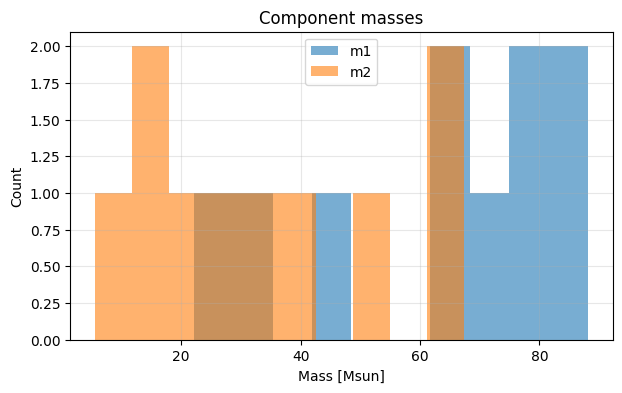

In [20]:
plt.figure(figsize=(7, 4))
plt.hist(m1, bins=10, alpha=0.6, label="m1")
plt.hist(m2, bins=10, alpha=0.6, label="m2")
plt.xlabel("Mass [Msun]")
plt.ylabel("Count")
plt.title("Component masses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

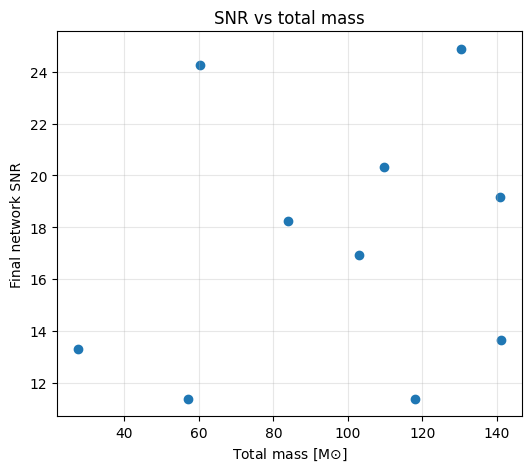

In [27]:
plt.figure(figsize=(6, 5))
plt.scatter(mtot, snrs)
plt.xlabel(r"Total mass [M$\odot$]")
plt.ylabel("Final network SNR")
plt.title("SNR vs total mass")
plt.grid(alpha=0.3)
plt.show()

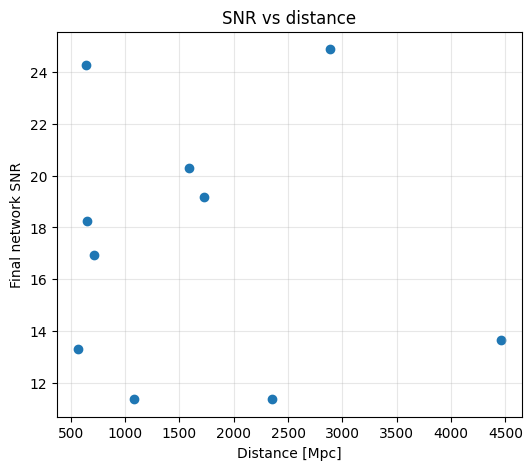

In [28]:
plt.figure(figsize=(6, 5))
plt.scatter(dist, snrs)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Final network SNR")
plt.title("SNR vs distance")
plt.grid(alpha=0.3)
plt.show()

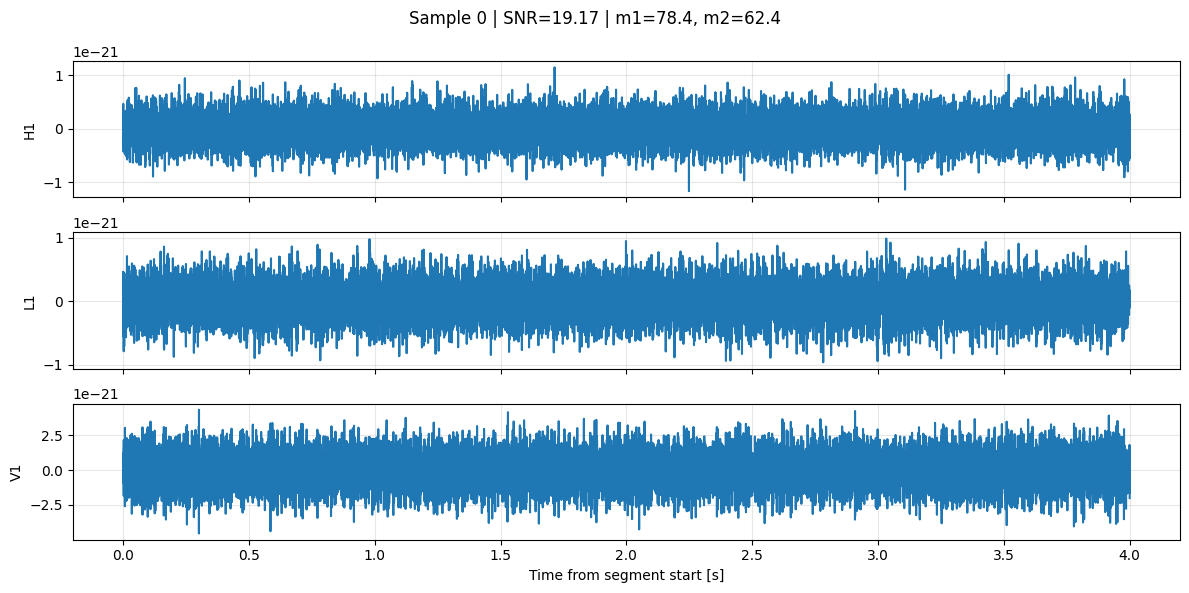

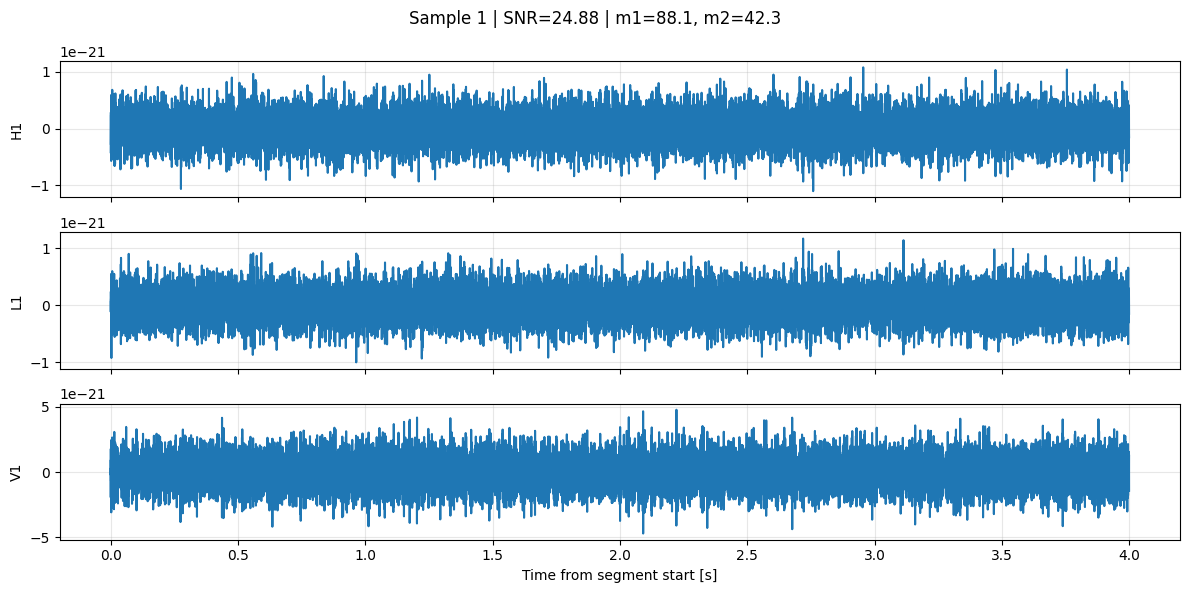

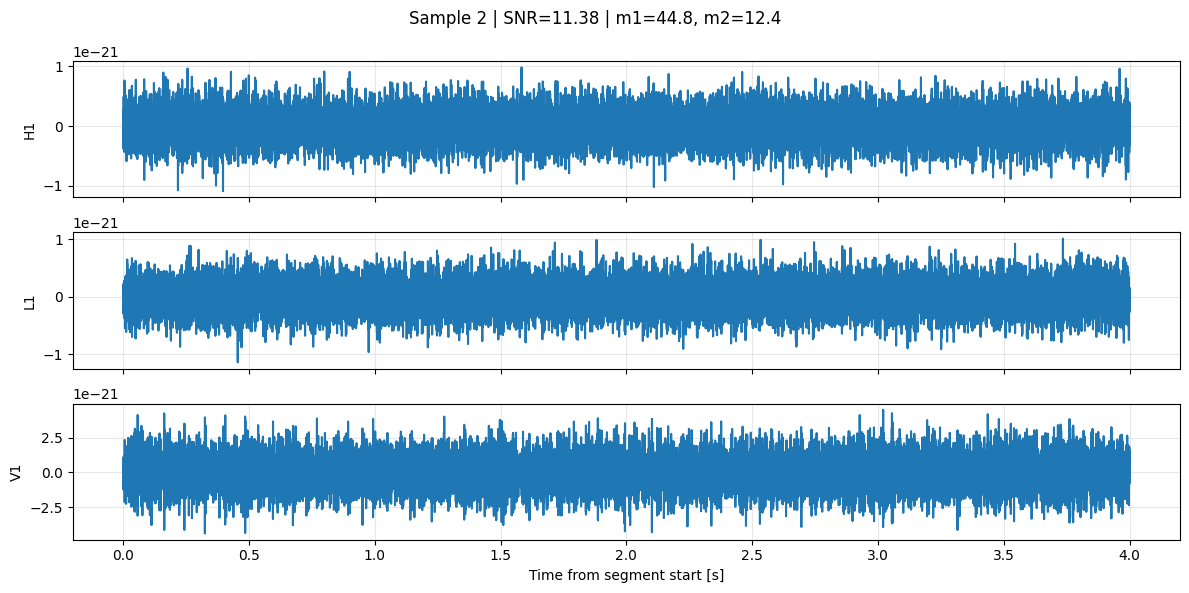

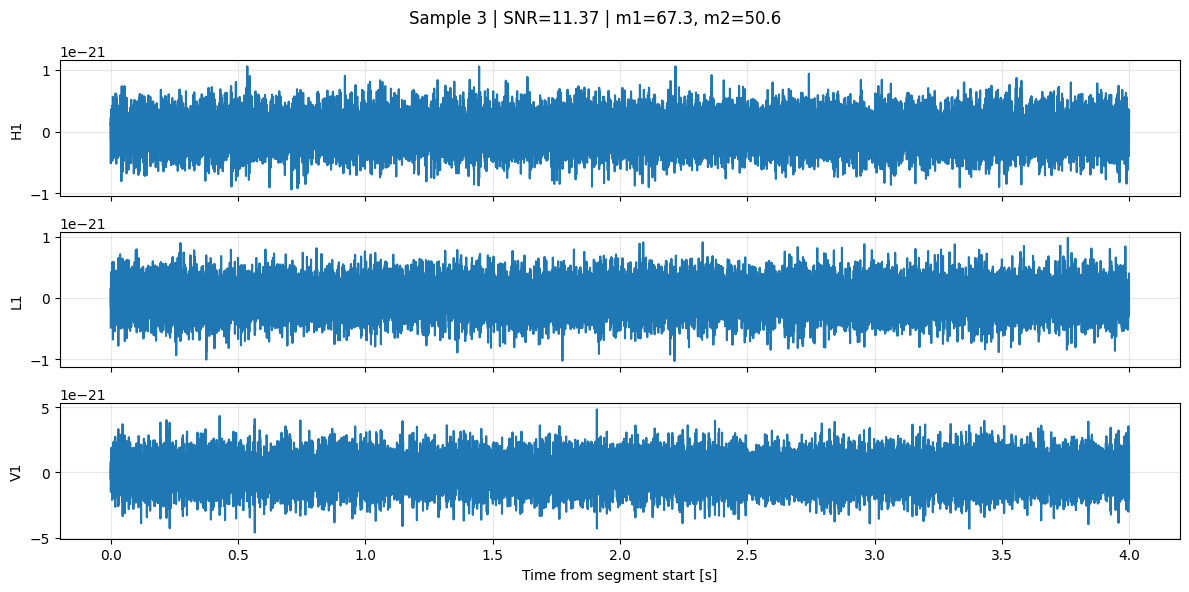

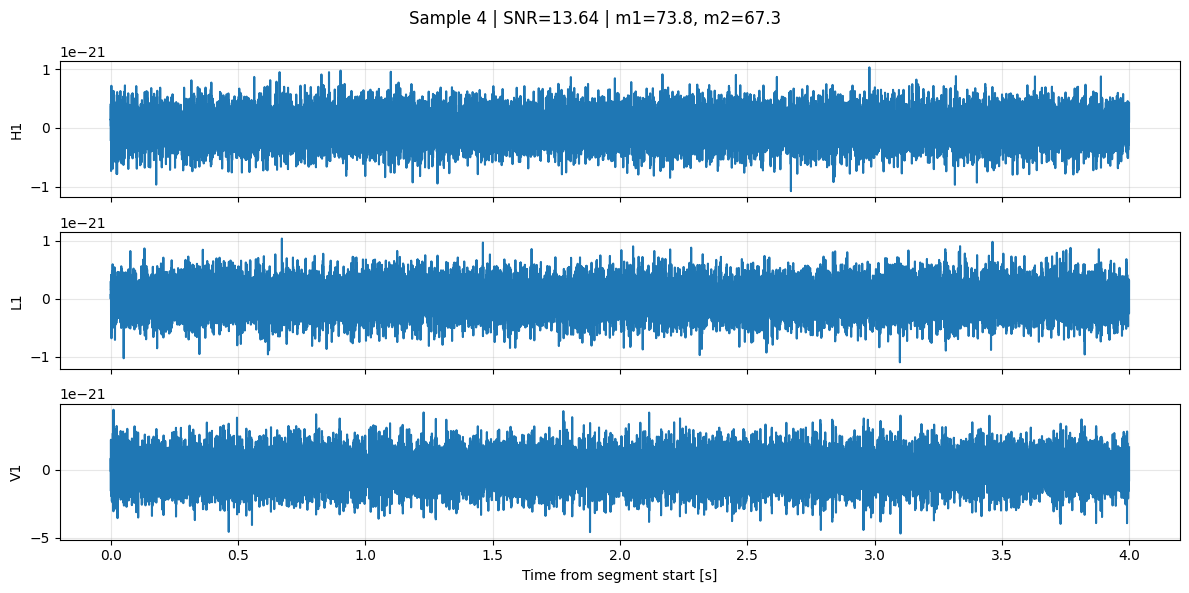

In [29]:
# For several signals
for i in range(min(5, len(batch10.X))):
    pseudo_sample = type("PseudoSample", (), {})()
    pseudo_sample.X = batch10.X[i]
    pseudo_sample.y = batch10.y[i]
    pseudo_sample.parameters = batch10.parameters[i]
    pseudo_sample.metadata = batch10.metadata[i]

    plot_sample(
        pseudo_sample,
        config,
        title=(
            f"Sample {i} | "
            f"SNR={pseudo_sample.metadata['snr']['final_network_snr']:.2f} | "
            f"m1={pseudo_sample.parameters.mass_1:.1f}, "
            f"m2={pseudo_sample.parameters.mass_2:.1f}"
        ),
    )

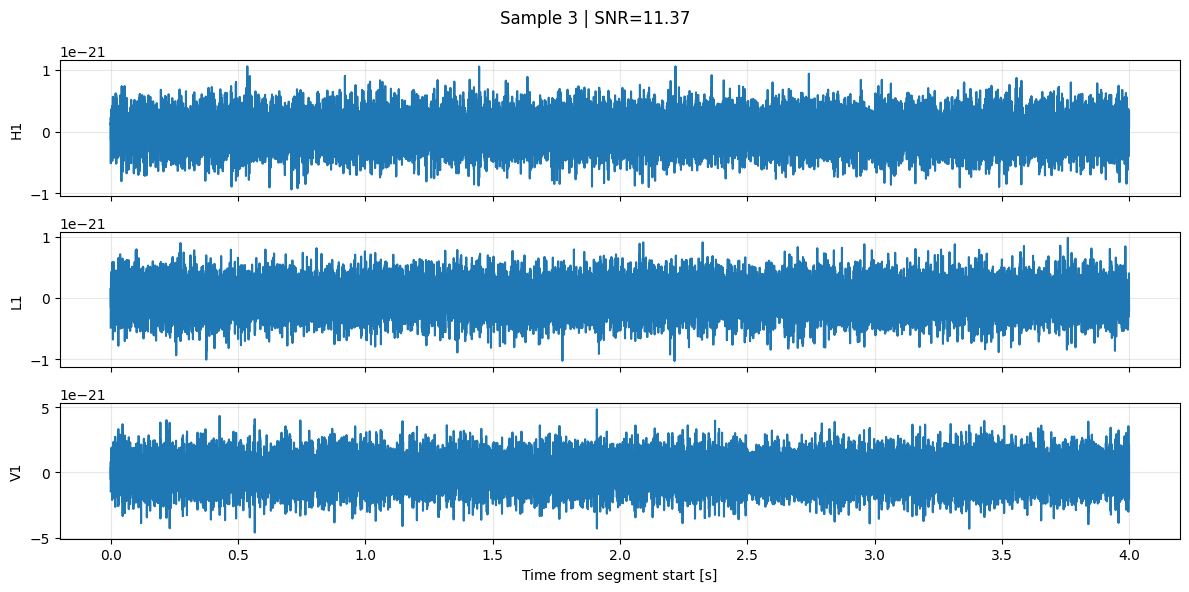

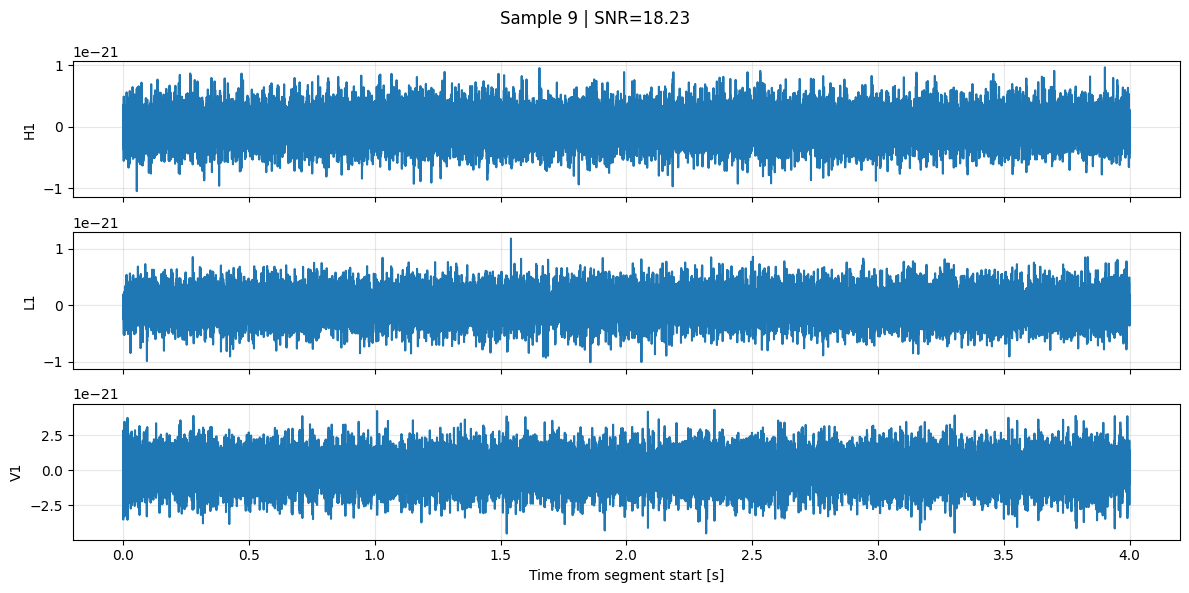

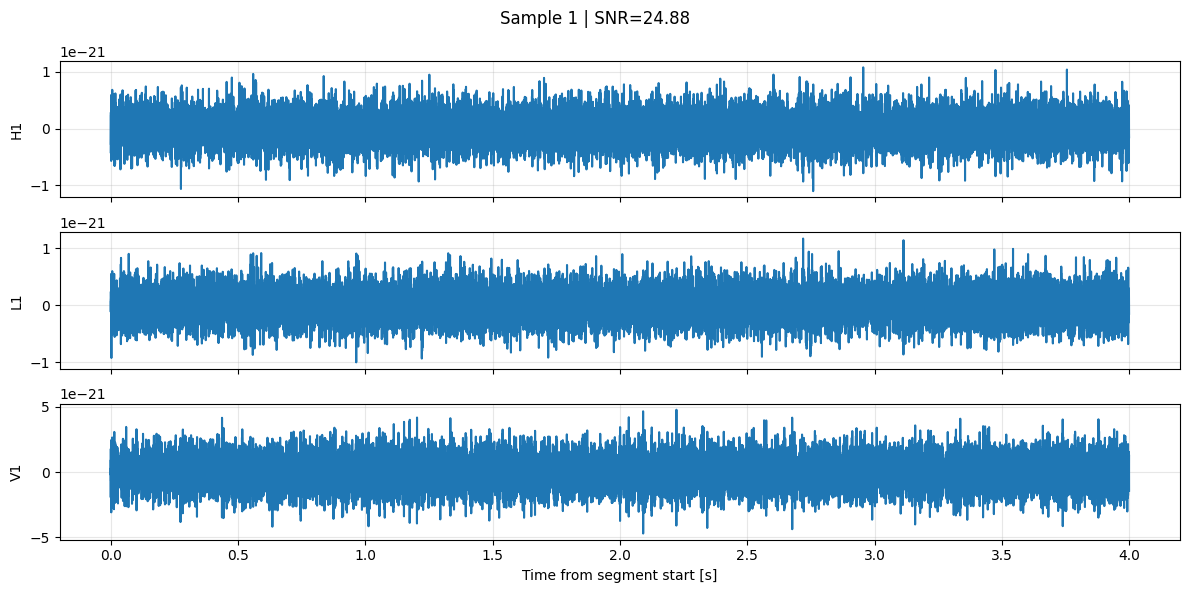

In [30]:
# SNR classification
idx_sorted = np.argsort(snrs)

indices_to_plot = [
    idx_sorted[0],
    idx_sorted[len(idx_sorted)//2],
    idx_sorted[-1],
]

for i in indices_to_plot:
    pseudo_sample = type("PseudoSample", (), {})()
    pseudo_sample.X = batch10.X[i]
    pseudo_sample.y = batch10.y[i]
    pseudo_sample.parameters = batch10.parameters[i]
    pseudo_sample.metadata = batch10.metadata[i]

    plot_sample(
        pseudo_sample,
        config,
        title=(
            f"Sample {i} | "
            f"SNR={pseudo_sample.metadata['snr']['final_network_snr']:.2f}"
        ),
    )

Now for n_samples=500

In [40]:
batch50 = builder.build_dataset(num_samples=500)

Built sample 10 of 500 --> 2.0% completed (attempts=10, failed=0, elapsed=3.3s, 0.33s/sample, 3.03 samples/s)
Built sample 20 of 500 --> 4.0% completed (attempts=20, failed=0, elapsed=6.8s, 0.34s/sample, 2.96 samples/s)
Built sample 30 of 500 --> 6.0% completed (attempts=30, failed=0, elapsed=10.3s, 0.34s/sample, 2.90 samples/s)
Built sample 40 of 500 --> 8.0% completed (attempts=40, failed=0, elapsed=13.5s, 0.34s/sample, 2.97 samples/s)
Built sample 50 of 500 --> 10.0% completed (attempts=50, failed=0, elapsed=16.7s, 0.33s/sample, 2.99 samples/s)
Built sample 60 of 500 --> 12.0% completed (attempts=60, failed=0, elapsed=20.1s, 0.34s/sample, 2.98 samples/s)
Built sample 70 of 500 --> 14.0% completed (attempts=70, failed=0, elapsed=23.8s, 0.34s/sample, 2.94 samples/s)
Built sample 80 of 500 --> 16.0% completed (attempts=80, failed=0, elapsed=27.2s, 0.34s/sample, 2.94 samples/s)
Built sample 90 of 500 --> 18.0% completed (attempts=90, failed=0, elapsed=30.6s, 0.34s/sample, 2.94 samples/s

In [43]:
snrs50 = np.array([
    m["snr"]["final_network_snr"]
    for m in batch50.metadata
])

truncated50 = np.array([
    m["windowing"]["is_truncated"]
    for m in batch50.metadata
])

rescaled50 = np.array([
    m["snr"]["snr_rescaled"]
    for m in batch50.metadata
])

any_clipped50 = np.array([
    any(m["injection"][det]["is_partially_clipped"] for det in m["detectors"])
    for m in batch50.metadata
])

print("X:", batch50.X.shape)
print("y:", batch50.y.shape)
print("SNR min/max/mean:", snrs50.min(), snrs50.max(), snrs50.mean())
print("Rescaled:", rescaled50.sum(), "/", len(rescaled50))
print("Truncated:", truncated50.sum(), "/", len(truncated50))
print("Clipped:", any_clipped50.sum(), "/", len(any_clipped50))

assert batch50.X.shape == (500, 3, config.length)
assert batch50.y.shape == (500, 3)
assert not np.any(any_clipped50)

low, high = config.target_network_snr_range
assert np.all(snrs50 >= low * (1 - config.snr_relative_tolerance))
assert np.all(snrs50 <= high * (1 + config.snr_relative_tolerance))

print("Batch 50 OK")

X: (500, 3, 16384)
y: (500, 3)
SNR min/max/mean: 10.001957408666202 24.966446988722883 17.023770121859865
Rescaled: 361 / 500
Truncated: 1 / 500
Clipped: 0 / 500
Batch 50 OK


##### DATASET
example: dataset_path = Path("/home/victor/gw/cbc_pe/data/cbc_pe/cbc_pe_4096_4s_30hz_10-25SNR.npz")

In [45]:
from pathlib import Path
import numpy as np

from src.io import save_dataset_npz, load_dataset_npz

dataset_path = save_dataset_npz(
    batch=batch50,
    output_dir=Path(PROJECT_ROOT / "data/debug"),
    file_name="bbh_debug_500.npz",
    detector_names=["H1", "L1", "V1"],
    overwrite=True,
    ask_before_overwrite=True,
)

loaded = load_dataset_npz(dataset_path)

print("Saved path:", dataset_path)
print("Loaded X:", loaded.X.shape)
print("Loaded y:", loaded.y.shape)
print("Loaded parameters:", len(loaded.parameters))
print("Loaded metadata:", len(loaded.metadata))
print("Dataset metadata keys:", loaded.dataset_metadata.keys())

Saved dataset arrays to '/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/debug/bbh_debug_500.npz'.
Saved dataset metadata to '/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/debug/bbh_debug_500.metadata.json'.
Saved path: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/debug/bbh_debug_500.npz
Loaded X: (500, 3, 16384)
Loaded y: (500, 3)
Loaded parameters: 500
Loaded metadata: 500
Dataset metadata keys: dict_keys(['dataset_file', 'num_samples', 'X_shape', 'y_shape', 'parameters', 'metadata'])


In [37]:
# Checks
assert loaded.X.shape == batch50.X.shape
assert loaded.y.shape == batch50.y.shape
assert len(loaded.parameters) == len(batch50.parameters)
assert len(loaded.metadata) == len(batch50.metadata)

assert np.allclose(loaded.X, batch50.X.astype(np.float32))
assert np.allclose(loaded.y, batch50.y.astype(np.float32))

assert loaded.dataset_metadata["num_samples"] == 50
assert loaded.dataset_metadata["X_shape"] == list(batch50.X.shape)
assert loaded.dataset_metadata["y_shape"] == list(batch50.y.shape)

print("Save/load OK")

Save/load OK
